In [1]:
# Array and data functions
from glob import glob
import numpy as np
import pandas as pd

# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from MEDUSSA.measure import SizeDataFrame
from MEDUSSA.transform import ParamSampler, ConfIntSampler
from MEDUSSA.utils import BorderRemoval

from tqdm import tqdm
from skimage import io

import warnings
warnings.filterwarnings('ignore')

/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
FM_segmentations = sorted(glob('/Users/reyesmatte/Desktop/copypasta/FM_vs_GFP/Deconvolved_FM/masks/Curated/*.tif'))

FM_dfs = []

for img in FM_segmentations:

    iptg = img.split('/')[-1].split('_')[1][:-2] + ' µM'

    img = BorderRemoval(io.imread(img))
    
    df = SizeDataFrame([img],from_files=False)

    df.insert(1,'IPTG',iptg)
    
    FM_dfs.append(df)

FM_df = pd.concat(FM_dfs)
FM_df.insert(0,'Fluorophore','FM 4-64')


In [3]:
GFP_segmentations = sorted(glob('/Users/reyesmatte/Desktop/copypasta/FM_vs_GFP/Deconvolved_FP/masks/Curated/*.tif'))

GFP_dfs = []

for img in GFP_segmentations:

    iptg = img.split('/')[-1].split('_')[1][:-2] + ' µM'

    img = BorderRemoval(io.imread(img))
    
    df = SizeDataFrame([img],from_files=False)

    df.insert(1,'IPTG',iptg)
    
    GFP_dfs.append(df)

GFP_df = pd.concat(GFP_dfs)
GFP_df.insert(0,'Fluorophore','mGreenLantern')


In [4]:
joint_df = pd.concat([FM_df,GFP_df],ignore_index=True).dropna()

w = ConfIntSampler(df=joint_df,columns=['Fluorophore','IPTG'],metric='Width')


In [14]:
FM_sampled = w[w['Fluorophore'] == 'FM 4-64']
GFP_sampled = w[w['Fluorophore'] == 'mGreenLantern']

FM_0um_mean = np.array(FM_sampled[FM_sampled['IPTG']=='0 µM'].groupby(['Fluorophore','IPTG']).median().reset_index()['Width'])[0]
GFP_0um_mean = np.array(GFP_sampled[GFP_sampled['IPTG']=='0 µM'].groupby(['Fluorophore','IPTG']).median().reset_index()['Width'])[0]

FM_sampled.insert(2,'Normalized_width',np.array(FM_sampled['Width'])/FM_0um_mean)
GFP_sampled.insert(2,'Normalized_width',np.array(GFP_sampled['Width'])/GFP_0um_mean)

joint_df_normalized = pd.concat([FM_sampled,GFP_sampled])

plot_order = ['0 µM','25 µM','50 µM','100 µM','500 µM','1000 µM']

joint_df_normalized.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS14_measures.csv')

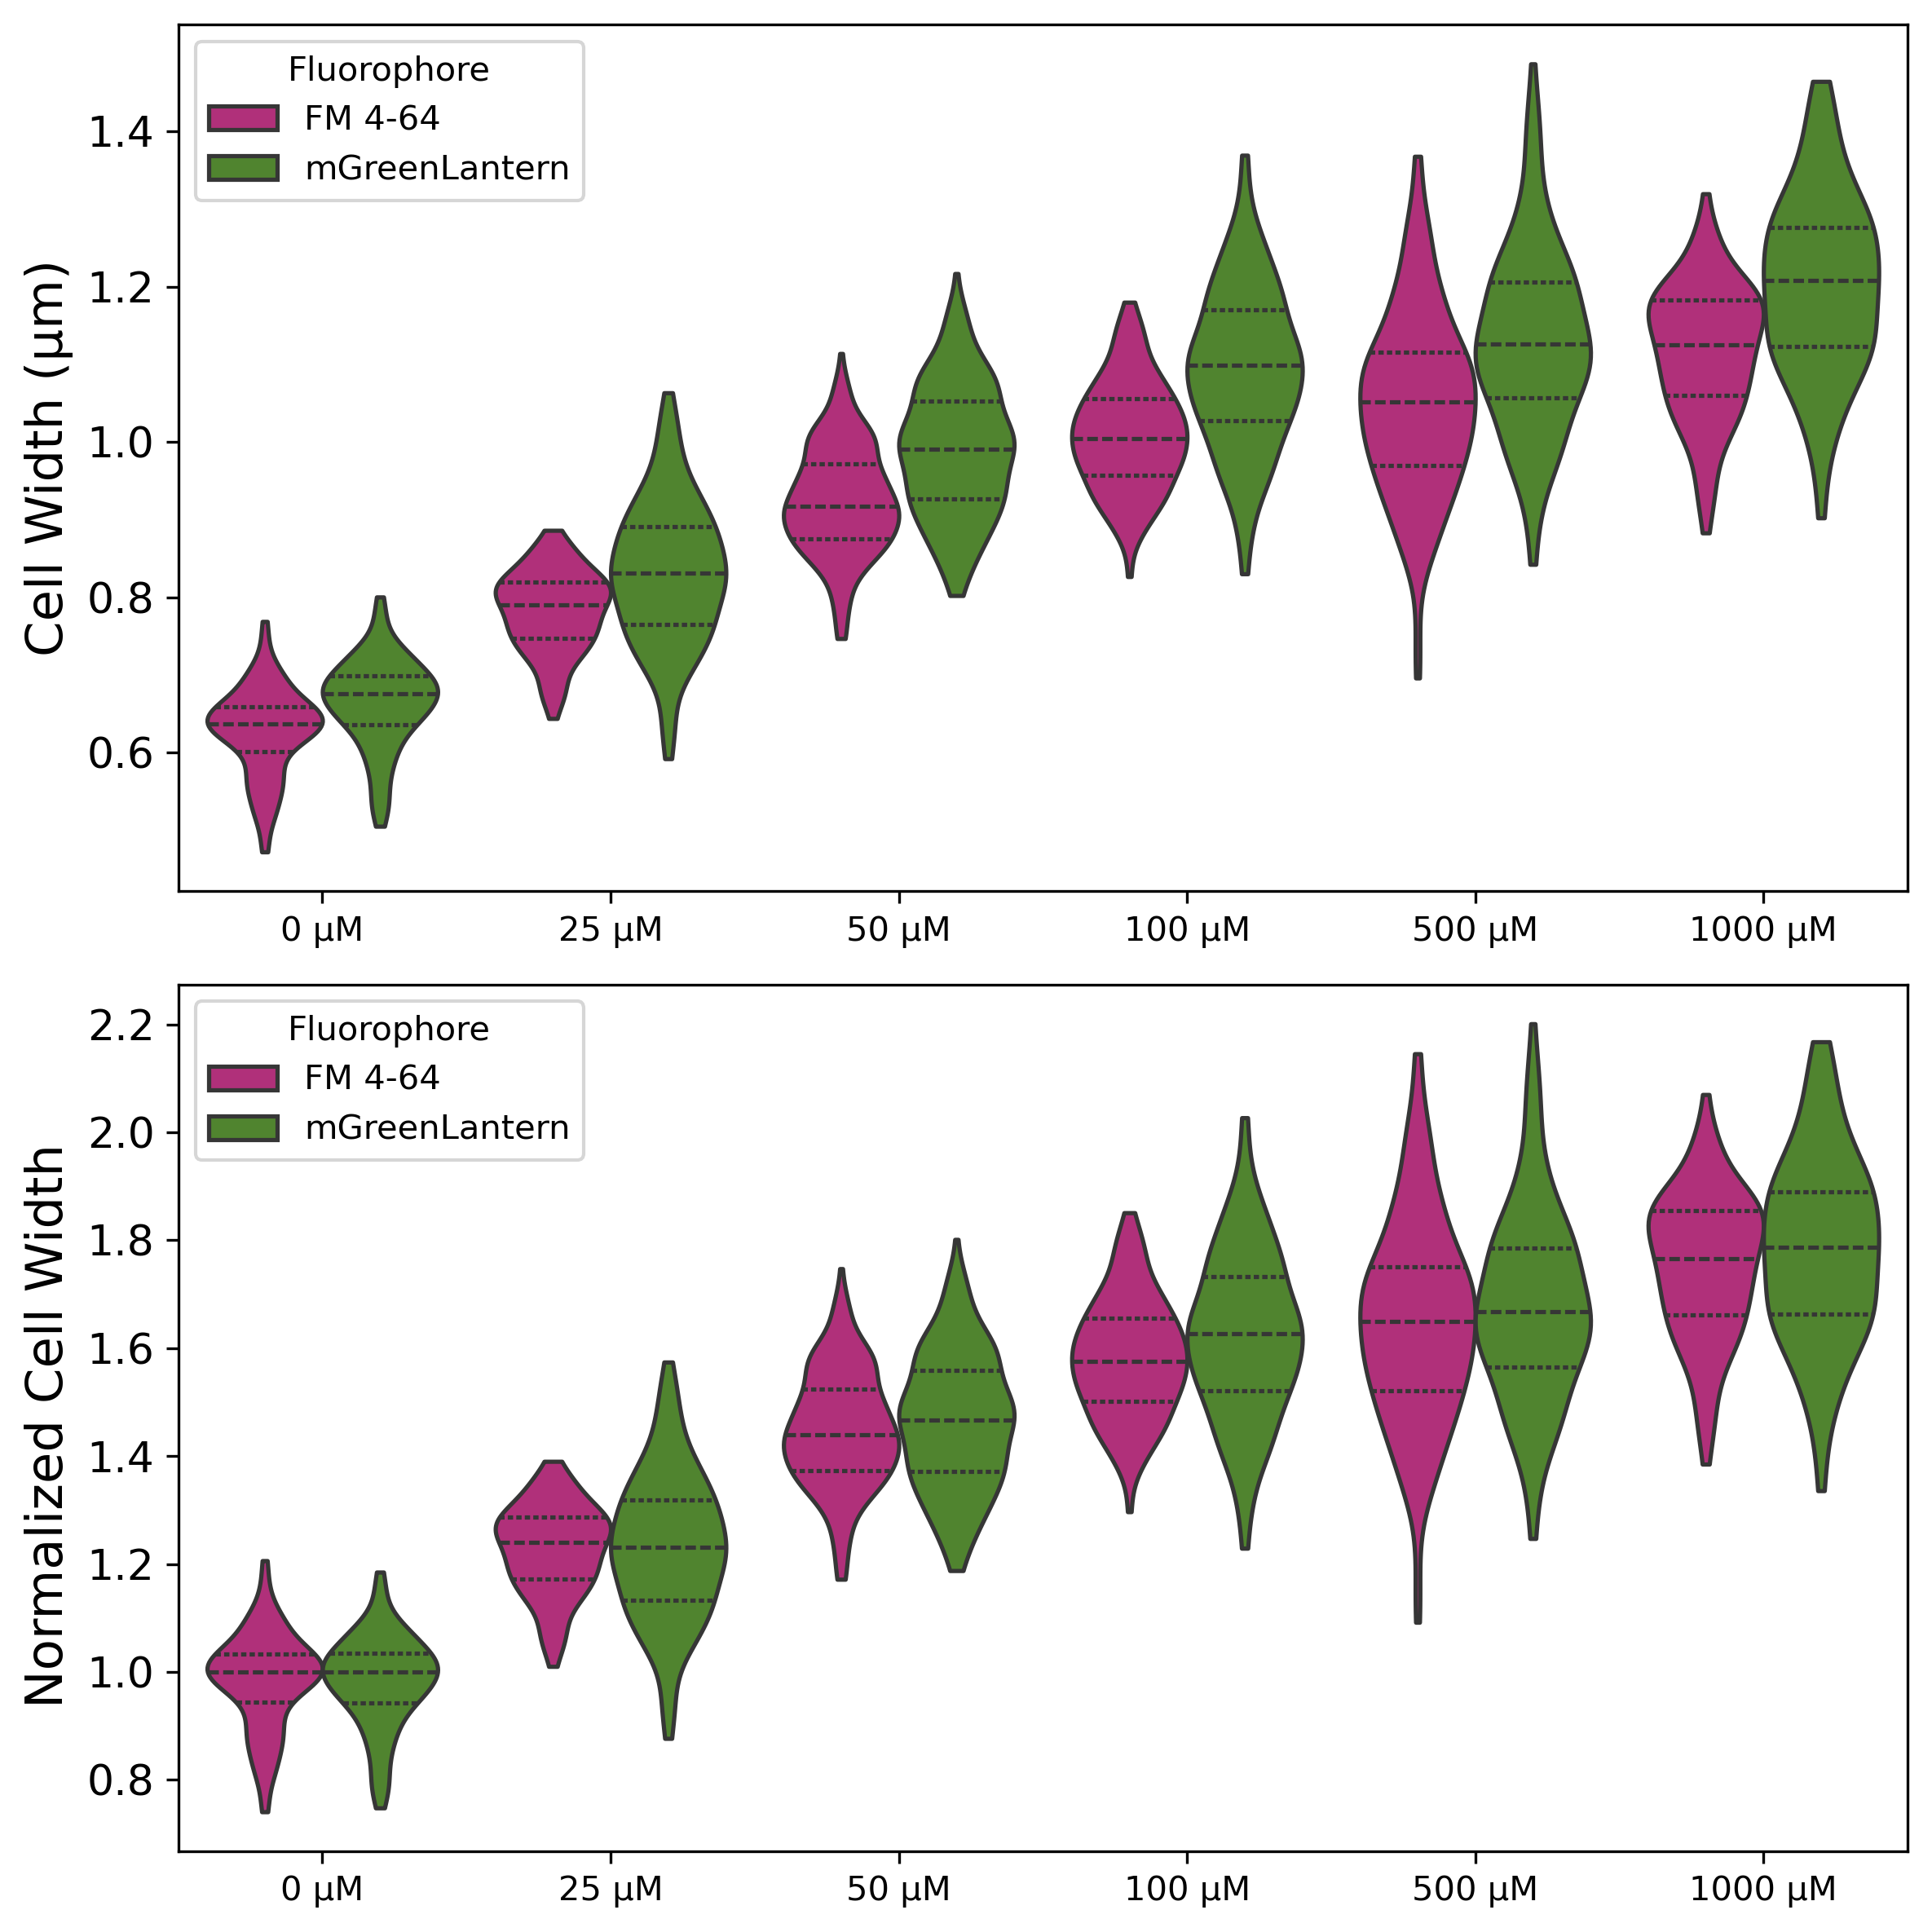

In [16]:
joint_df_normalized = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS14_measures.csv')
plot_order = ['0 µM','25 µM','50 µM','100 µM','500 µM','1000 µM']

fig,ax = plt.subplots(dpi=300,figsize=(8,8),nrows=2)

sns.violinplot(data=joint_df_normalized,x='IPTG',y='Width',hue='Fluorophore',order=plot_order,ax=ax[0],inner='quart',scale='width',cut=0,palette=['#c51b7d','#4d9221'])
ax[0].set_yticklabels(ax[0].get_yticklabels(),fontsize=12.5)
ax[0].set_xlabel('')
ax[0].set_ylabel('Cell Width (µm)',fontsize=15)

sns.violinplot(data=joint_df_normalized,x='IPTG',y='Normalized_width',hue='Fluorophore',order=plot_order,ax=ax[1],inner='quart',scale='width',cut=0,palette=['#c51b7d','#4d9221'])
ax[1].set_yticklabels(ax[1].get_yticklabels(),fontsize=12.5)
ax[1].set_xlabel('')
ax[1].set_ylabel('Normalized Cell Width ',fontsize=15)

fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS14/FigS14_FM_GFP_population.png')

In [9]:
w.groupby(['Fluorophore','IPTG']).size().reset_index()

,Fluorophore,IPTG,0
0,FM 4-64,0 µM,189
1,FM 4-64,100 µM,287
2,FM 4-64,1000 µM,180
3,FM 4-64,25 µM,133
4,FM 4-64,50 µM,332
5,FM 4-64,500 µM,193
6,GFP,0 µM,145
7,GFP,100 µM,268
8,GFP,1000 µM,171
9,GFP,25 µM,214


In [22]:
fm_width_means = FM_sampled[['IPTG','Width']].groupby('IPTG').median().reset_index()
fm_width_means_arr = np.array(fm_width_means['Width'])

gfp_width_means = GFP_sampled[['IPTG','Width']].groupby('IPTG').median().reset_index()
gfp_width_means_arr = np.array(gfp_width_means['Width'])

ratios = fm_width_means_arr/gfp_width_means_arr